# Benchmark inicial de modelos de pose para ergonomia

Objetivo:
- fijar un dataset inicial razonable para el caso real
- preparar un subset pequeno, equilibrado y reproducible
- comparar `MediaPipe Pose`, `YOLO Pose` y `MoveNet` sin reentrenar

Decision de arranque:
- usamos `posture_correction_v4` como baseline inicial
- motivo: es el dataset mas cercano al producto final, con webcam frontal y mucho mas volumen

En esta fase solo buscamos una primera senal tecnica: si los keypoints son estables y utiles para reglas ergonomicas.

Configuracion de dispositivos:
- `YOLO Pose` usa GPU si `torch` la detecta
- `MoveNet` se ejecuta en CPU por defecto para evitar problemas de entorno
- `MediaPipe Pose` se ejecuta en CPU

In [1]:
from __future__ import annotations

import json
import os
import random
import shutil
import subprocess
import sys
import time
import urllib.request
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("ABSL_LOGGING_MIN_LOG_LEVEL", "3")

SEED = 7
random.seed(SEED)


def progress(iterable, **kwargs):
    try:
        from tqdm import tqdm

        return tqdm(iterable, **kwargs)
    except ImportError:
        return iterable


def detect_torch_cuda() -> bool:
    try:
        import torch

        return bool(torch.cuda.is_available())
    except Exception:
        return False


YOLO_USE_GPU = detect_torch_cuda()
BENCHMARK_DEVICE = 0 if YOLO_USE_GPU else "cpu"
MOVENET_DEVICE = os.getenv("POSE_MOVENET_DEVICE", "cpu")
MEDIAPIPE_DEVICE = "cpu"

EVALUATION_MODE = os.getenv("POSE_BENCHMARK_MODE", "full_dataset")
EVALUATION_IMAGE_LIMIT = int(os.environ["POSE_BENCHMARK_LIMIT"]) if os.getenv("POSE_BENCHMARK_LIMIT") else None
SUBSET_MAX_PER_GROUP = 60
SUBSET_MAX_TOTAL = 180
WARMUP_IMAGES_PER_MODEL = 2
YOLO_WEIGHTS = "yolov8s-pose.pt"


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / ".git").exists():
            return candidate
    return current


PROJECT_ROOT = find_project_root()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR = PROJECT_ROOT / "notebooks" / "pose_benchmark" / "results"

RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"RAW_DATA_DIR: {RAW_DATA_DIR}")
print(f"RESULTS_DIR: {RESULTS_DIR}")

PROJECT_ROOT: /home/veleiro/OneDrive/Clase/3º de IA/2º Cuatri/Proyecto Integrador I/Proyecto/Proyecto-Integrador-I
RAW_DATA_DIR: /home/veleiro/OneDrive/Clase/3º de IA/2º Cuatri/Proyecto Integrador I/Proyecto/Proyecto-Integrador-I/data/raw
RESULTS_DIR: /home/veleiro/OneDrive/Clase/3º de IA/2º Cuatri/Proyecto Integrador I/Proyecto/Proyecto-Integrador-I/notebooks/pose_benchmark/results


## 1. Datasets disponibles

Los cinco recursos quedan registrados aqui con:
- una descripcion corta
- la ruta local donde queremos guardarlos
- la configuracion de descarga de Roboflow

El dataset activo se cambia con una sola variable: `ACTIVE_DATASET_KEY`.

In [2]:
DATASETS = {
    "sitting_posture_4keypoint": {
        "label": "Sitting Posture 4 keypoint",
        "notes": "Mayormente lateral. Buen punto de partida para el benchmark base.",
        "local_dir": RAW_DATA_DIR / "ikornproject_sitting-posture-rofqf_v4",
        "download": {
            "workspace": "ikornproject",
            "project": "sitting-posture-rofqf",
            "version": 4,
            "format": "coco",
        },
    },
    "sitting_posture_folder_v1": {
        "label": "Sitting Posture folder",
        "notes": "Alternativa simple por carpetas. Se descarga desde el proyecto publico original.",
        "local_dir": RAW_DATA_DIR / "pablos_sitting_posture_folder_v1",
        "download": {
            "workspace": "dataset-sqm0h",
            "project": "sitting-posture-ezkda",
            "version": 1,
            "format": "folder",
        },
    },
    "desk_posture_coco_v1": {
        "label": "Desk Posture coco",
        "notes": "Util para validacion visual porque ya trae puntos marcados. Version publica disponible: v9.",
        "local_dir": RAW_DATA_DIR / "pablos_desk_posture_coco_v1",
        "download": {
            "workspace": "roboflow-test-o7w8z",
            "project": "desk-posture",
            "version": 9,
            "format": "coco",
        },
    },
    "posture_detection_folder_v1": {
        "label": "Posture Detection folder",
        "notes": "Segundo contraste con estructura por carpetas. Se descarga desde el proyecto publico original.",
        "local_dir": RAW_DATA_DIR / "pablos_posture_detection_folder_v1",
        "download": {
            "workspace": "posture-magj9",
            "project": "posture_detection-5huqr",
            "version": 1,
            "format": "folder",
        },
    },
    "posture_correction_v4_folder_v1": {
        "label": "Posture Correction v4 folder",
        "notes": "Webcam frontal. Se parece mas al caso final del proyecto. Se descarga desde el proyecto publico original.",
        "local_dir": RAW_DATA_DIR / "pablos_posture_correction_v4_folder_v1",
        "download": {
            "workspace": "posturecorrection",
            "project": "posture_correction_v4",
            "version": 1,
            "format": "folder",
        },
    },
}

ACTIVE_DATASET_KEY = "posture_correction_v4_folder_v1"
ACTIVE_DATASET = DATASETS[ACTIVE_DATASET_KEY]
RAW_DATASET_OVERRIDE = None

SUBSET_DIR = PROJECT_ROOT / "data" / "pose_subset" / ACTIVE_DATASET_KEY
(SUBSET_DIR / "images").mkdir(parents=True, exist_ok=True)

print("Dataset activo:", ACTIVE_DATASET_KEY)
print("Descripcion:", ACTIVE_DATASET["notes"])
print("Ruta esperada:", ACTIVE_DATASET["local_dir"])

Dataset activo: posture_correction_v4_folder_v1
Descripcion: Webcam frontal. Se parece mas al caso final del proyecto. Se descarga desde el proyecto publico original.
Ruta esperada: /home/veleiro/OneDrive/Clase/3º de IA/2º Cuatri/Proyecto Integrador I/Proyecto/Proyecto-Integrador-I/data/raw/pablos_posture_correction_v4_folder_v1


## 2. Descarga opcional con Roboflow

Si ya teneis los datasets descargados, podeis saltar esta parte.
Si no, este helper os permite bajarlos a una ruta fija dentro de `data/raw/`.

Requisito:
- definir `ROBOFLOW_API_KEY` en el entorno antes de ejecutar la descarga

In [3]:
%pip install roboflow


def get_roboflow_client():
    import os
    from roboflow import Roboflow

    api_key = os.getenv("ROBOFLOW_API_KEY")
    if not api_key:
        raise ValueError("Falta ROBOFLOW_API_KEY en el entorno.")
    return Roboflow(api_key=api_key)


def download_dataset(dataset_key: str):
    cfg = DATASETS[dataset_key]
    target_dir = cfg["local_dir"]
    download_cfg = cfg["download"]

    # El SDK de Roboflow no descarga si la carpeta destino ya existe.
    # Si la carpeta existe pero esta vacia, la eliminamos antes de lanzar la descarga.
    if target_dir.exists():
        if any(target_dir.iterdir()):
            print(f"La carpeta ya tiene contenido: {target_dir}")
            print("Se reutiliza el contenido existente y no se vuelve a descargar.")
            return target_dir
        target_dir.rmdir()

    client = get_roboflow_client()
    project = client.workspace(download_cfg["workspace"]).project(download_cfg["project"])
    version = project.version(download_cfg["version"])
    downloaded = version.download(download_cfg["format"], location=str(target_dir))

    downloaded_path = Path(downloaded.location)
    downloaded_files = [path for path in downloaded_path.rglob("*") if path.is_file()]
    if not downloaded_files:
        raise RuntimeError(
            f"Roboflow devolvio la ruta {downloaded.location}, pero no aparecio ningun archivo descargado."
        )

    print(f"Descargado: {dataset_key}")
    print(f"Ruta local: {downloaded.location}")
    print(f"Archivos detectados: {len(downloaded_files)}")
    return downloaded


list(DATASETS)

Note: you may need to restart the kernel to use updated packages.


['sitting_posture_4keypoint',
 'sitting_posture_folder_v1',
 'desk_posture_coco_v1',
 'posture_detection_folder_v1',
 'posture_correction_v4_folder_v1']

In [4]:
# Ejecuta solo las lineas que necesites.

# download_dataset("sitting_posture_4keypoint")
# download_dataset("sitting_posture_folder_v1")
# download_dataset("desk_posture_coco_v1")
# download_dataset("posture_detection_folder_v1")
# download_dataset("posture_correction_v4_folder_v1")

## 3. Preparar el subset

Para la comparativa inicial no hace falta usar todo el dataset.
Aun asi, en este notebook dejamos dos modos:
- `subset`: mas rapido y equilibrado por clase
- `full_dataset`: usa todas las imagenes disponibles

Importante:
- en `posture_correction_v4` las carpetas son clases de postura, no keypoints
- estas etiquetas solo se usan aqui para balancear el subset y comparar por categoria
- la evaluacion de pose la siguen haciendo los modelos preentrenados

In [5]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def looks_like_dataset_root(path: Path) -> bool:
    if not path.exists() or not path.is_dir():
        return False

    child_dirs = {child.name.lower() for child in path.iterdir() if child.is_dir()}
    child_files = {child.name.lower() for child in path.iterdir() if child.is_file()}

    return bool(
        {"train", "valid"} <= child_dirs
        or "images" in child_dirs
        or {"data.yaml", "readme.roboflow.txt", "readme.dataset.txt"} & child_files
    )


def resolve_dataset_root(dataset_key: str, override: Path | None = None) -> Path | None:
    if override is not None:
        override = Path(override)
        if override.exists():
            return override

    base_dir = DATASETS[dataset_key]["local_dir"]
    if looks_like_dataset_root(base_dir):
        return base_dir

    for candidate in sorted(base_dir.rglob("*")):
        if candidate.is_dir() and looks_like_dataset_root(candidate):
            return candidate

    return None


def list_image_files(root: Path) -> list[Path]:
    return sorted(
        path for path in root.rglob("*") if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )


def infer_group(image_path: Path, source_root: Path) -> str:
    relative = image_path.relative_to(source_root)
    parts = relative.parts
    split_names = {"train", "valid", "test"}

    if len(parts) >= 3 and parts[0].lower() in split_names and parts[1].lower() not in {"images", "labels"}:
        return parts[1]

    if len(parts) >= 2 and parts[0].lower() not in split_names:
        return parts[0]

    if len(parts) >= 1 and parts[0].lower() in split_names:
        return parts[0]

    return "unlabeled"


def infer_split(image_path: Path, source_root: Path) -> str | None:
    relative = image_path.relative_to(source_root)
    if relative.parts and relative.parts[0].lower() in {"train", "valid", "test"}:
        return relative.parts[0]
    return None


def collect_image_records(source_root: Path) -> list[dict]:
    records = []
    image_files = list_image_files(source_root)
    for image_path in progress(image_files, desc="Escaneando imagenes", leave=False):
        records.append(
            {
                "image_path": image_path,
                "group": infer_group(image_path, source_root),
                "split": infer_split(image_path, source_root),
            }
        )
    return records


def build_subset(
    records: list[dict],
    target_dir: Path,
    max_per_group: int = 4,
    max_total: int = 18,
    seed: int = SEED,
) -> list[dict]:
    rng = random.Random(seed)
    images_dir = target_dir / "images"
    images_dir.mkdir(parents=True, exist_ok=True)

    for existing_file in images_dir.glob("*"):
        if existing_file.is_file():
            existing_file.unlink()

    grouped_records: dict[str, list[dict]] = {}
    for record in records:
        grouped_records.setdefault(record["group"], []).append(record)

    selected_records = []
    for group, group_records in sorted(grouped_records.items()):
        shuffled_records = group_records[:]
        rng.shuffle(shuffled_records)
        selected_records.extend(shuffled_records[:max_per_group])

    rng.shuffle(selected_records)
    selected_records = selected_records[:max_total]

    manifest = []
    for index, record in enumerate(
        progress(selected_records, desc="Copiando subset", leave=False),
        start=1,
    ):
        source_path = record["image_path"]
        safe_group = record["group"].replace(" ", "_").replace("/", "_")
        target_path = images_dir / f"{index:03d}_{safe_group}_{source_path.name}"
        shutil.copy2(source_path, target_path)
        manifest.append(
            {
                "index": index,
                "group": record["group"],
                "split": record["split"],
                "source_path": str(source_path),
                "subset_path": str(target_path),
            }
        )

    return manifest


dataset_root = resolve_dataset_root(ACTIVE_DATASET_KEY, RAW_DATASET_OVERRIDE)
subset_manifest = []
full_manifest = []
evaluation_manifest = []

if dataset_root is None:
    print("Dataset no encontrado.")
    print("Ruta esperada:", ACTIVE_DATASET["local_dir"])
else:
    source_root = dataset_root / "images" if (dataset_root / "images").exists() else dataset_root
    records = collect_image_records(source_root)
    subset_manifest = build_subset(
        records,
        SUBSET_DIR,
        max_per_group=SUBSET_MAX_PER_GROUP,
        max_total=SUBSET_MAX_TOTAL,
    )
    full_manifest = [
        {
            "index": index,
            "group": record["group"],
            "split": record["split"],
            "source_path": str(record["image_path"]),
            "subset_path": str(record["image_path"]),
        }
        for index, record in enumerate(records, start=1)
    ]
    evaluation_manifest = full_manifest if EVALUATION_MODE == "full_dataset" else subset_manifest

    print("Dataset detectado en:", dataset_root)
    print("Imagenes encontradas:", len(records))
    print("Subset creado en:", SUBSET_DIR / "images")
    print("Tamano del subset:", len(subset_manifest))
    print("Modo de evaluacion:", EVALUATION_MODE)
    print("Imagenes a evaluar:", len(evaluation_manifest))

Dataset detectado en: /home/veleiro/OneDrive/Clase/3º de IA/2º Cuatri/Proyecto Integrador I/Proyecto/Proyecto-Integrador-I/data/raw/pablos_posture_correction_v4_folder_v1
Imagenes encontradas: 4666
Subset creado en: /home/veleiro/OneDrive/Clase/3º de IA/2º Cuatri/Proyecto Integrador I/Proyecto/Proyecto-Integrador-I/data/pose_subset/posture_correction_v4_folder_v1/images
Tamano del subset: 180
Modo de evaluacion: full_dataset
Imagenes a evaluar: 4666


### 3.1 Resumen visual del dataset y del subset

,split,group,count
0,test,looks good,105
1,test,sit up straight,386
2,test,straighten head,184
3,train,looks good,837
4,train,sit up straight,1663
5,train,straighten head,809
6,valid,looks good,163
7,valid,sit up straight,297
8,valid,straighten head,222


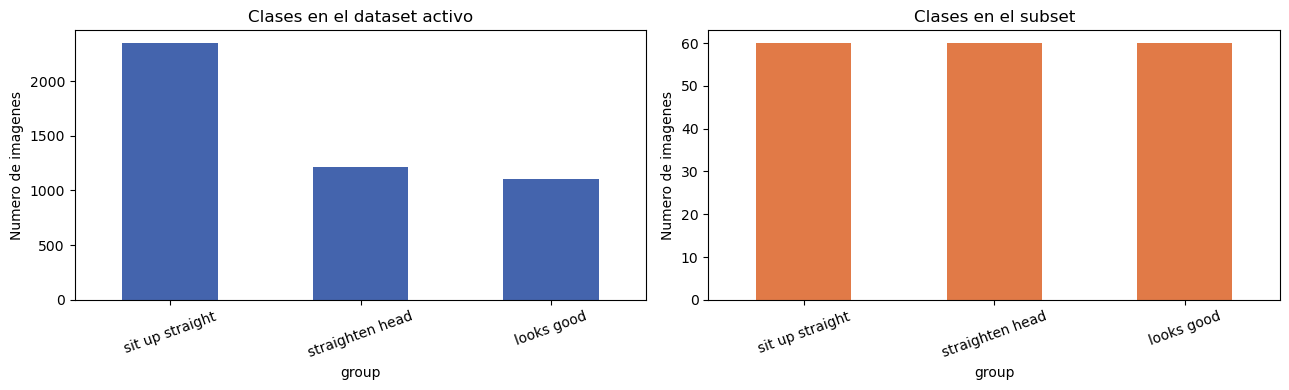

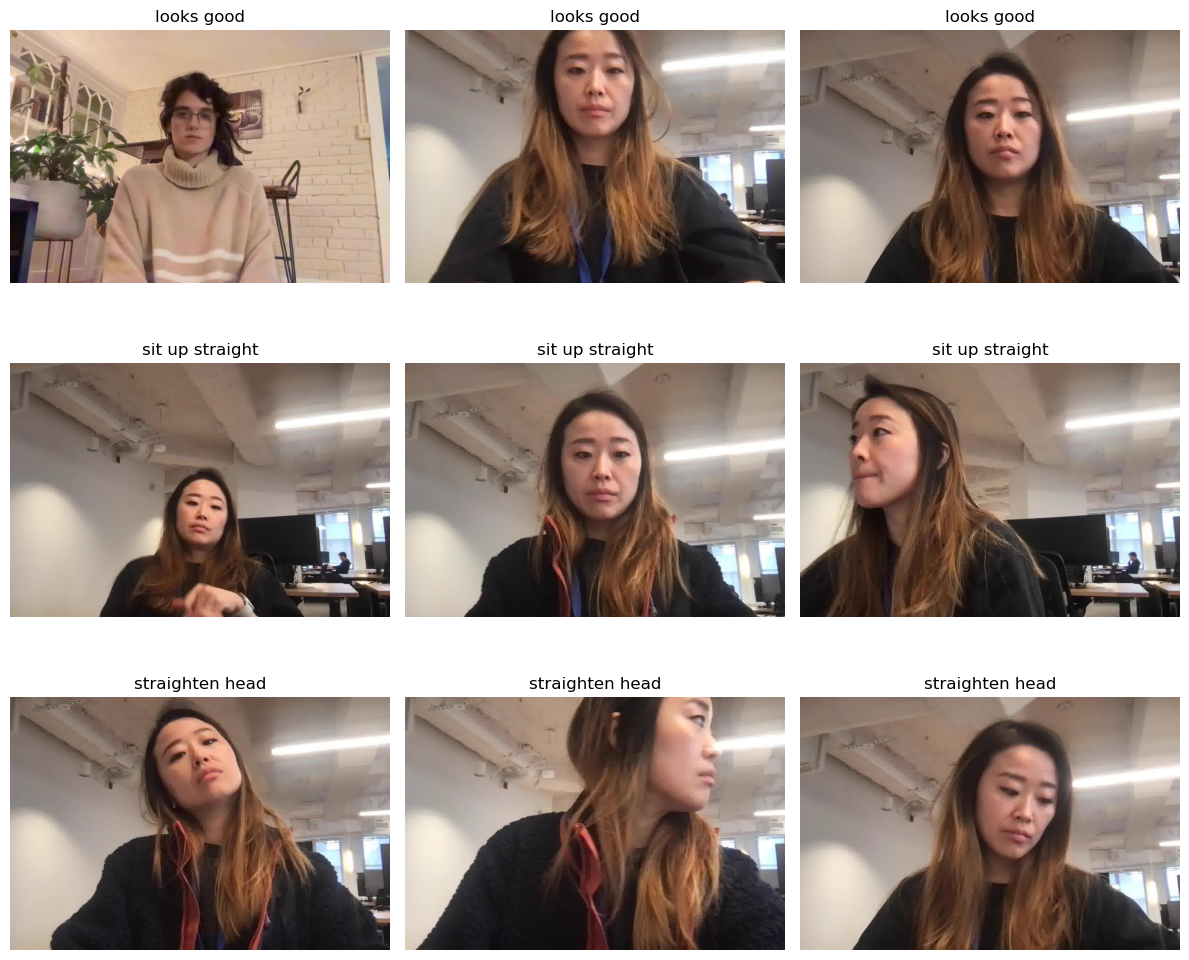

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image


dataset_df = pd.DataFrame(records) if dataset_root is not None else pd.DataFrame()
subset_df = pd.DataFrame(subset_manifest) if subset_manifest else pd.DataFrame()

if not dataset_df.empty:
    display(
        dataset_df.groupby(["split", "group"], dropna=False)
        .size()
        .rename("count")
        .reset_index()
        .sort_values(["split", "group"])
    )

if not dataset_df.empty:
    dataset_counts = dataset_df.groupby("group").size().sort_values(ascending=False)
    subset_counts = subset_df.groupby("group").size().reindex(dataset_counts.index, fill_value=0)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    dataset_counts.plot(kind="bar", ax=axes[0], color="#4464ad")
    axes[0].set_title("Clases en el dataset activo")
    axes[0].set_ylabel("Numero de imagenes")
    axes[0].tick_params(axis="x", rotation=20)

    subset_counts.plot(kind="bar", ax=axes[1], color="#e17a47")
    axes[1].set_title("Clases en el subset")
    axes[1].set_ylabel("Numero de imagenes")
    axes[1].tick_params(axis="x", rotation=20)

    plt.tight_layout()
    plt.show()


def show_subset_samples(manifest: list[dict], samples_per_group: int = 3) -> None:
    if not manifest:
        print("No hay subset para mostrar.")
        return

    grouped: dict[str, list[Path]] = {}
    for item in manifest:
        grouped.setdefault(item["group"], []).append(Path(item["subset_path"]))

    groups = sorted(grouped)
    fig, axes = plt.subplots(len(groups), samples_per_group, figsize=(4 * samples_per_group, 3.5 * len(groups)))

    if len(groups) == 1:
        axes = [axes]

    for row_idx, group in enumerate(groups):
        selected = grouped[group][:samples_per_group]
        row_axes = axes[row_idx] if samples_per_group > 1 else [axes[row_idx]]
        for col_idx in range(samples_per_group):
            ax = row_axes[col_idx]
            ax.axis("off")
            if col_idx < len(selected):
                image = Image.open(selected[col_idx])
                ax.imshow(image)
                ax.set_title(group)

    plt.tight_layout()
    plt.show()


show_subset_samples(subset_manifest, samples_per_group=3)

## 4. Dependencias y entorno de ejecucion

In [7]:
%pip install opencv-python mediapipe ultralytics tensorflow tensorflow-hub pandas tqdm


def check_optional_dependencies() -> dict[str, bool]:
    import importlib.util

    package_checks = {
        "opencv-python": "cv2",
        "mediapipe": "mediapipe",
        "ultralytics": "ultralytics",
        "tensorflow": "tensorflow",
        "tensorflow-hub": "tensorflow_hub",
        "pandas": "pandas",
        "tqdm": "tqdm",
    }

    status = {}
    for label, import_name in package_checks.items():
        status[label] = importlib.util.find_spec(import_name) is not None
    return status


dependency_status = check_optional_dependencies()
dependency_status

Note: you may need to restart the kernel to use updated packages.


{'opencv-python': True,
 'mediapipe': True,
 'ultralytics': True,
 'tensorflow': True,
 'tensorflow-hub': True,
 'pandas': True,
 'tqdm': True}

In [8]:
def inspect_runtime() -> pd.DataFrame:
    import pandas as pd

    rows: list[dict[str, str]] = [
        {
            "item": "Modo de ejecucion",
            "value": "Auto",
        },
        {
            "item": "Dispositivo YOLO",
            "value": str(BENCHMARK_DEVICE),
        },
        {
            "item": "Dispositivo MoveNet",
            "value": MOVENET_DEVICE,
        },
        {
            "item": "Dispositivo MediaPipe",
            "value": MEDIAPIPE_DEVICE,
        },
        {
            "item": "Pesos YOLO",
            "value": YOLO_WEIGHTS,
        },
        {
            "item": "Modo evaluacion",
            "value": EVALUATION_MODE,
        },
    ]

    try:
        command = subprocess.run(
            ["nvidia-smi", "-L"],
            check=False,
            capture_output=True,
            text=True,
            timeout=5,
        )
        gpu_value = command.stdout.strip() if command.returncode == 0 else command.stderr.strip() or "sin salida"
    except FileNotFoundError:
        gpu_value = "nvidia-smi no disponible en este entorno"
    except Exception as exc:
        gpu_value = f"No se pudo consultar: {exc}"

    rows.append({"item": "nvidia-smi", "value": gpu_value})

    try:
        import torch

        rows.append({"item": "Torch CUDA disponible", "value": str(torch.cuda.is_available())})
        rows.append({"item": "Torch num dispositivos", "value": str(torch.cuda.device_count())})
        if torch.cuda.is_available():
            rows.append({"item": "Torch GPU 0", "value": torch.cuda.get_device_name(0)})
    except Exception as exc:
        rows.append({"item": "Torch", "value": f"Error: {exc}"})

    try:
        import tensorflow as tf

        rows.append(
            {
                "item": "TensorFlow GPU visible",
                "value": str(bool(tf.config.list_physical_devices("GPU"))),
            }
        )
    except Exception as exc:
        rows.append({"item": "TensorFlow", "value": f"Error: {exc}"})

    try:
        import mediapipe as mp

        backend = "solutions" if hasattr(mp, "solutions") else "tasks" if hasattr(mp, "tasks") else "desconocido"
        rows.append({"item": "MediaPipe backend", "value": backend})
    except Exception as exc:
        rows.append({"item": "MediaPipe", "value": f"Error: {exc}"})

    return pd.DataFrame(rows)


runtime_df = inspect_runtime()
display(runtime_df)

I0000 00:00:1774805200.206367   75614 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774805201.555908   75614 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


,item,value
0,Modo de ejecucion,Auto
1,Dispositivo YOLO,0
2,Dispositivo MoveNet,cpu
3,Dispositivo MediaPipe,cpu
4,Pesos YOLO,yolov8s-pose.pt
5,Modo evaluacion,full_dataset
6,nvidia-smi,GPU 0: NVIDIA GeForce RTX 3060 Laptop GPU (UUI...
7,Torch CUDA disponible,True
8,Torch num dispositivos,1
9,Torch GPU 0,NVIDIA GeForce RTX 3060 Laptop GPU


## 5. Modelos y benchmark

In [9]:
MEDIAPIPE_REQUIRED_IDS = {
    "nose": 0,
    "left_shoulder": 11,
    "right_shoulder": 12,
    "left_elbow": 13,
    "right_elbow": 14,
    "left_hip": 23,
    "right_hip": 24,
}

COCO_REQUIRED_IDS = {
    "nose": 0,
    "left_shoulder": 5,
    "right_shoulder": 6,
    "left_elbow": 7,
    "right_elbow": 8,
    "left_hip": 11,
    "right_hip": 12,
}

MEDIAPIPE_TASK_MODEL_PATH = PROJECT_ROOT / "models" / "mediapipe" / "pose_landmarker_lite.task"
MEDIAPIPE_TASK_MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/pose_landmarker/"
    "pose_landmarker_lite/float16/latest/pose_landmarker_lite.task"
)


def ensure_mediapipe_task_model() -> Path:
    if MEDIAPIPE_TASK_MODEL_PATH.exists() and MEDIAPIPE_TASK_MODEL_PATH.stat().st_size > 0:
        return MEDIAPIPE_TASK_MODEL_PATH

    MEDIAPIPE_TASK_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
    with urllib.request.urlopen(MEDIAPIPE_TASK_MODEL_URL) as response, open(MEDIAPIPE_TASK_MODEL_PATH, "wb") as fh:
        total = int(response.headers.get("Content-Length", 0))
        chunk_size = 1024 * 1024
        expected_steps = (total + chunk_size - 1) // chunk_size if total else None
        iterator = progress(
            iter(lambda: response.read(chunk_size), b""),
            total=expected_steps,
            desc=f"Descargando {MEDIAPIPE_TASK_MODEL_PATH.name}",
            unit="chunk",
            leave=False,
        )
        for chunk in iterator:
            fh.write(chunk)

    return MEDIAPIPE_TASK_MODEL_PATH


POSE_BATCH_RUNNER = PROJECT_ROOT / "notebooks" / "pose_benchmark" / "run_pose_batch.py"


def limit_manifest_balanced(manifest: list[dict], max_images: int | None, seed: int = SEED) -> list[dict]:
    if max_images is None or max_images >= len(manifest):
        return manifest

    rng = random.Random(seed)
    buckets: dict[tuple[str | None, str | None], list[dict]] = {}
    for item in manifest:
        bucket_key = (item.get("split"), item.get("group"))
        buckets.setdefault(bucket_key, []).append(item)

    for items in buckets.values():
        rng.shuffle(items)

    ordered_keys = sorted(buckets)
    selected: list[dict] = []
    while len(selected) < max_images:
        progress_made = False
        for bucket_key in ordered_keys:
            bucket = buckets[bucket_key]
            if not bucket:
                continue
            selected.append(bucket.pop())
            progress_made = True
            if len(selected) >= max_images:
                break
        if not progress_made:
            break

    return selected


def run_model_batch_subprocess(model_name: str, manifest: list[dict]) -> list[dict]:
    input_path = RESULTS_DIR / f"_{model_name}_input.json"
    output_path = RESULTS_DIR / f"_{model_name}_output.json"
    payload = [
        {
            "image_path": item["image_path"],
            "group": item.get("group"),
            "split": item.get("split"),
        }
        for item in manifest
    ]
    input_path.write_text(json.dumps(payload))

    command = [
        sys.executable,
        str(POSE_BATCH_RUNNER),
        "--model",
        model_name,
        "--input-json",
        str(input_path),
        "--output-json",
        str(output_path),
        "--warmup-images",
        str(WARMUP_IMAGES_PER_MODEL),
        "--min-confidence",
        "0.3",
        "--yolo-weights",
        YOLO_WEIGHTS,
        "--yolo-device",
        str(BENCHMARK_DEVICE) if BENCHMARK_DEVICE != "cpu" else "cpu",
        "--movenet-device",
        MOVENET_DEVICE,
        "--mediapipe-model-path",
        str(MEDIAPIPE_TASK_MODEL_PATH),
        "--mediapipe-model-url",
        MEDIAPIPE_TASK_MODEL_URL,
    ]

    env = dict(os.environ)
    env.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
    env.setdefault("ABSL_LOGGING_MIN_LOG_LEVEL", "3")
    if model_name == "movenet" and MOVENET_DEVICE == "cpu":
        env["CUDA_VISIBLE_DEVICES"] = "-1"

    completed = subprocess.run(command, check=False, env=env)
    if completed.returncode != 0:
        raise subprocess.CalledProcessError(completed.returncode, command)

    if not output_path.exists():
        raise FileNotFoundError(f"No se encontro la salida esperada para {model_name}: {output_path}")

    return json.loads(output_path.read_text())


def run_benchmark(
    manifest: list[dict],
    model_names: tuple[str, ...] = ("yolo_pose", "movenet", "mediapipe_pose"),
    max_images: int | None = None,
) -> list[dict]:
    selected_manifest = limit_manifest_balanced(manifest, max_images=max_images)
    runtime_manifest = [
        {
            "image_path": str(Path(item["subset_path"])),
            "group": item.get("group"),
            "split": item.get("split"),
        }
        for item in selected_manifest
    ]

    results = []
    for model_name in model_names:
        try:
            print(f"Lanzando benchmark aislado para: {model_name}")
            results.extend(run_model_batch_subprocess(model_name, runtime_manifest))
            print(f"Modelo ejecutado correctamente: {model_name}")
        except Exception as exc:
            print(f"No se pudo ejecutar {model_name} en subproceso: {exc}")

    return results


benchmark_results = []

if not evaluation_manifest:
    print("No hay imagenes para evaluar. Ejecuta antes la preparacion del dataset.")
else:
    benchmark_results = run_benchmark(evaluation_manifest, max_images=EVALUATION_IMAGE_LIMIT)
    benchmark_results[:5]

Lanzando benchmark aislado para: yolo_pose


Modelo ejecutado correctamente: yolo_pose
Lanzando benchmark aislado para: movenet


I0000 00:00:1774805255.634927   76249 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774805256.704043   76249 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/veleiro/anaconda3/envs/vpc2/lib/python3.10/site-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
E0000 00:00:1774805257.916117   76249 cuda_platform.cc:52] f

Modelo ejecutado correctamente: movenet
Lanzando benchmark aislado para: mediapipe_pose


I0000 00:00:1774805328.494264   76855 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774805329.545259   76855 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774805330.650016   76937 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1774805330.652361   76950 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.25.10.1), renderer: Mesa Intel(R) Iris(R) Xe Graphics (TGL GT2)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1774805330.689458   76941 inference_feedback_manager.cc:114] Feedback manager requires a

Modelo ejecutado correctamente: mediapipe_pose


## 6. Resumen y graficas

Registros generados: 13998
Errores: 0


,model,backend,image_name,group,split,runtime_ms,required_keypoints_present,required_keypoint_rate,neck_ready,trunk_ready,upper_limb_ready,upper_body_ready,full_ergonomic_ready,error
0,yolo_pose,torch_cuda:0,extract0757_jpg.rf.649d916c13f9ada6c3413d45411...,looks good,test,10.674296,3,0.428571,True,False,False,False,False,None
1,yolo_pose,torch_cuda:0,extract0876_jpg.rf.2598747659f819876775cd9932f...,looks good,test,10.754063,3,0.428571,True,False,False,False,False,None
2,yolo_pose,torch_cuda:0,extract0877_jpg.rf.ddf5603aec4c2f244208dce9fd6...,looks good,test,10.907943,3,0.428571,True,False,False,False,False,None
3,yolo_pose,torch_cuda:0,extract0878_jpg.rf.06e745794cc44ebaaa2033094d7...,looks good,test,10.290639,3,0.428571,True,False,False,False,False,None
4,yolo_pose,torch_cuda:0,extract0879_jpg.rf.f944c729e46feef1d6039dccad5...,looks good,test,10.102608,3,0.428571,True,False,False,False,False,None
5,yolo_pose,torch_cuda:0,extract0880_jpg.rf.467f37cf2251b6ea29ee89d0f0d...,looks good,test,10.231689,3,0.428571,True,False,False,False,False,None
6,yolo_pose,torch_cuda:0,extract0903_jpg.rf.0373172455053c05c0be140bb41...,looks good,test,10.453647,3,0.428571,True,False,False,False,False,None
7,yolo_pose,torch_cuda:0,extract0905_jpg.rf.1bb6d45905f0112daa97deef80b...,looks good,test,10.352629,3,0.428571,True,False,False,False,False,None
8,yolo_pose,torch_cuda:0,extract0923_jpg.rf.854edb1f8e4fc4865c43d8aff9f...,looks good,test,10.652684,3,0.428571,True,False,False,False,False,None
9,yolo_pose,torch_cuda:0,extract0925_jpg.rf.41a97d3913b468e78a51f8cab5a...,looks good,test,10.358335,3,0.428571,True,False,False,False,False,None


,backend,runtime_ms_mean,runtime_ms_median,total_keypoints,confident_keypoints,required_keypoints_present,required_keypoint_rate,neck_ready_pct,trunk_ready_pct,upper_limb_ready_pct,upper_body_ready_pct,full_ergonomic_ready_pct,error_rate
model,,,,,,,,,,,,,
mediapipe_pose,mediapipe_tasks,22.745031,22.524099,32.950493,15.203601,4.406129,62.944706,99.849979,0.192885,84.204886,84.204886,0.192885,0.0
movenet,tensorflow_cpu,8.694882,8.541164,17.000000,7.952207,3.722460,53.178005,95.927990,8.872696,41.705958,41.405915,8.486927,0.0
yolo_pose,torch_cuda:0,10.241464,9.534728,17.000000,7.209601,3.130733,44.724757,100.000000,0.000000,9.194171,9.194171,0.000000,0.0


,group,model,backend,samples,runtime_ms_median,required_keypoint_rate,neck_ready_pct,trunk_ready_pct,upper_limb_ready_pct,upper_body_ready_pct,full_ergonomic_ready_pct
0,looks good,mediapipe_pose,mediapipe_tasks,1105,22.691321,62.714932,100.000000,0.000000,84.162896,84.162896,0.000000
1,looks good,movenet,tensorflow_cpu,1105,8.462498,58.009050,99.909502,16.108597,48.778281,48.778281,15.656109
2,looks good,yolo_pose,torch_cuda:0,1105,9.686514,45.248869,100.000000,0.000000,10.859729,10.859729,0.000000
3,sit up straight,mediapipe_pose,mediapipe_tasks,2346,22.503167,62.574595,99.701620,0.341006,82.566070,82.566070,0.341006
4,sit up straight,movenet,tensorflow_cpu,2346,8.526657,51.376203,94.799659,6.692242,38.150043,38.064791,6.393862
5,sit up straight,yolo_pose,torch_cuda:0,2346,9.607209,44.172452,100.000000,0.000000,6.990622,6.990622,0.000000
6,straighten head,mediapipe_pose,mediapipe_tasks,1215,22.464116,63.868313,100.000000,0.082305,87.407407,87.407407,0.082305
7,straighten head,movenet,tensorflow_cpu,1215,8.653019,52.263374,94.485597,6.502058,42.139918,41.152263,6.008230
8,straighten head,yolo_pose,torch_cuda:0,1215,9.385015,45.314521,100.000000,0.000000,11.934156,11.934156,0.000000


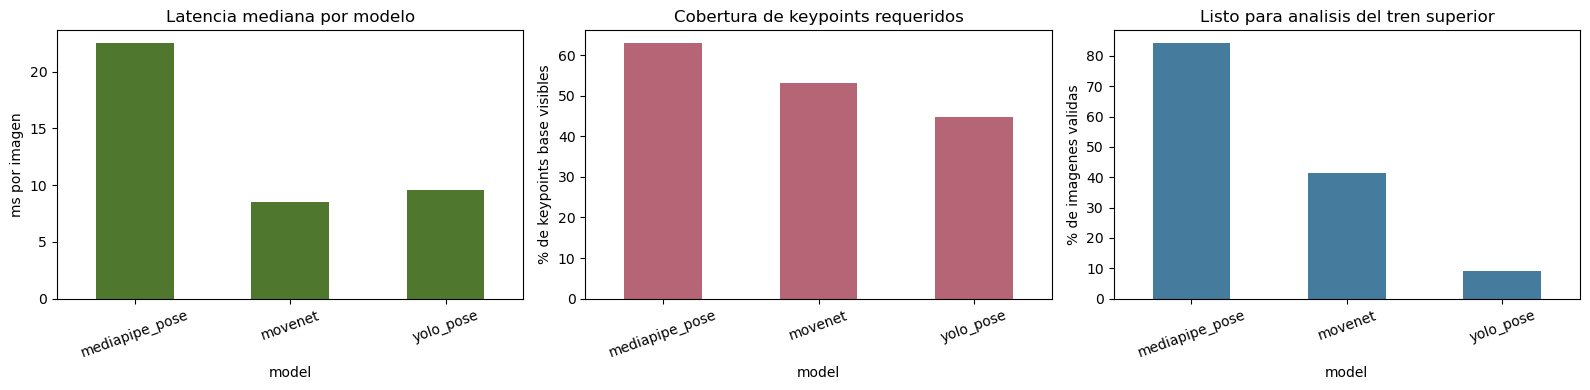

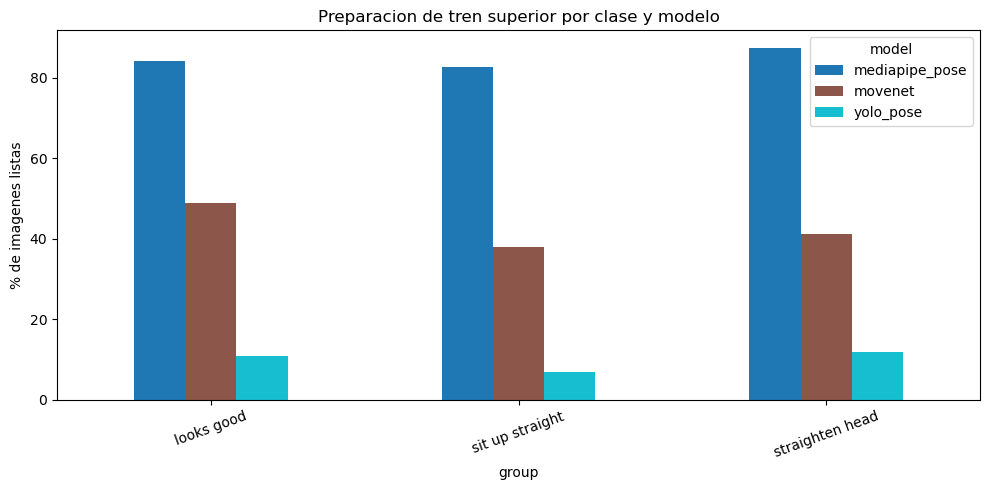

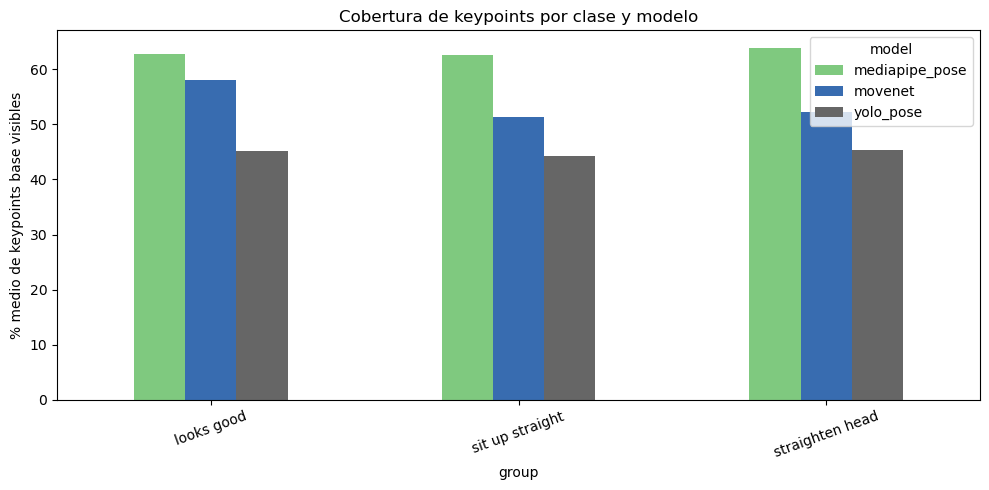

Resultados guardados en: /home/veleiro/OneDrive/Clase/3º de IA/2º Cuatri/Proyecto Integrador I/Proyecto/Proyecto-Integrador-I/notebooks/pose_benchmark/results


In [10]:
def summarize_results(records: list[dict]):
    if not records:
        print("No hay resultados todavia.")
        return None, None, None

    import pandas as pd

    df = pd.DataFrame(records)
    if "backend" not in df:
        df["backend"] = "desconocido"
    valid_df = df[df["error"].isna()].copy()
    summary = (
        valid_df.groupby("model", dropna=False)
        .agg(
            backend=("backend", lambda values: ", ".join(sorted({str(value) for value in values.dropna()}))),
            runtime_ms_mean=("runtime_ms", "mean"),
            runtime_ms_median=("runtime_ms", "median"),
            total_keypoints=("total_keypoints", "mean"),
            confident_keypoints=("confident_keypoints", "mean"),
            required_keypoints_present=("required_keypoints_present", "mean"),
            required_keypoint_rate=("required_keypoint_rate", "mean"),
            neck_ready_pct=("neck_ready", "mean"),
            trunk_ready_pct=("trunk_ready", "mean"),
            upper_limb_ready_pct=("upper_limb_ready", "mean"),
            upper_body_ready_pct=("upper_body_ready", "mean"),
            full_ergonomic_ready_pct=("full_ergonomic_ready", "mean"),
        )
        .sort_values(by=["upper_body_ready_pct", "required_keypoint_rate", "runtime_ms_median"], ascending=[False, False, True])
    )
    error_rate = df.groupby("model")["error"].apply(lambda values: values.notna().mean()).rename("error_rate")
    summary = summary.join(error_rate, how="left")

    percentage_columns = [
        "required_keypoint_rate",
        "neck_ready_pct",
        "trunk_ready_pct",
        "upper_limb_ready_pct",
        "upper_body_ready_pct",
        "full_ergonomic_ready_pct",
        "error_rate",
    ]
    for column in percentage_columns:
        summary[column] = summary[column] * 100

    group_summary = (
        valid_df.groupby(["group", "model"], dropna=False)
        .agg(
            backend=("backend", lambda values: ", ".join(sorted({str(value) for value in values.dropna()}))),
            samples=("model", "size"),
            runtime_ms_median=("runtime_ms", "median"),
            required_keypoint_rate=("required_keypoint_rate", "mean"),
            neck_ready_pct=("neck_ready", "mean"),
            trunk_ready_pct=("trunk_ready", "mean"),
            upper_limb_ready_pct=("upper_limb_ready", "mean"),
            upper_body_ready_pct=("upper_body_ready", "mean"),
            full_ergonomic_ready_pct=("full_ergonomic_ready", "mean"),
        )
        .reset_index()
        .sort_values(["group", "upper_body_ready_pct", "required_keypoint_rate", "runtime_ms_median"], ascending=[True, False, False, True])
    )
    for column in [
        "required_keypoint_rate",
        "neck_ready_pct",
        "trunk_ready_pct",
        "upper_limb_ready_pct",
        "upper_body_ready_pct",
        "full_ergonomic_ready_pct",
    ]:
        group_summary[column] = group_summary[column] * 100

    return df, summary, group_summary


if benchmark_results:
    df_results, df_summary, df_group_summary = summarize_results(benchmark_results)
    print(f"Registros generados: {len(df_results)}")
    print(f"Errores: {int(df_results['error'].notna().sum())}")
    display(
        df_results[
            [
                "model",
                "backend",
                "image_name",
                "group",
                "split",
                "runtime_ms",
                "required_keypoints_present",
                "required_keypoint_rate",
                "neck_ready",
                "trunk_ready",
                "upper_limb_ready",
                "upper_body_ready",
                "full_ergonomic_ready",
                "error",
            ]
        ].head(12)
    )
    display(df_summary)
    display(df_group_summary.head(12))

    model_success = df_results.groupby("model")["upper_body_ready"].mean().mul(100).sort_values(ascending=False)
    model_by_group = (
        df_results.groupby(["group", "model"])["upper_body_ready"]
        .mean()
        .mul(100)
        .unstack()
        .sort_index()
    )
    model_coverage_by_group = (
        df_results.groupby(["group", "model"])["required_keypoint_rate"]
        .mean()
        .mul(100)
        .unstack()
        .sort_index()
    )

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    df_summary["runtime_ms_median"].plot(kind="bar", ax=axes[0], color="#4f772d")
    axes[0].set_title("Latencia mediana por modelo")
    axes[0].set_ylabel("ms por imagen")
    axes[0].tick_params(axis="x", rotation=20)

    df_summary["required_keypoint_rate"].plot(kind="bar", ax=axes[1], color="#b56576")
    axes[1].set_title("Cobertura de keypoints requeridos")
    axes[1].set_ylabel("% de keypoints base visibles")
    axes[1].tick_params(axis="x", rotation=20)

    model_success.plot(kind="bar", ax=axes[2], color="#457b9d")
    axes[2].set_title("Listo para analisis del tren superior")
    axes[2].set_ylabel("% de imagenes validas")
    axes[2].tick_params(axis="x", rotation=20)

    plt.tight_layout()
    fig.savefig(RESULTS_DIR / "pose_benchmark_overview.png", dpi=160, bbox_inches="tight")
    plt.show()

    if not model_by_group.empty:
        fig_group, ax = plt.subplots(figsize=(10, 5))
        model_by_group.plot(kind="bar", ax=ax, colormap="tab10")
        ax.set_title("Preparacion de tren superior por clase y modelo")
        ax.set_ylabel("% de imagenes listas")
        ax.tick_params(axis="x", rotation=20)
        plt.tight_layout()
        fig_group.savefig(RESULTS_DIR / "pose_benchmark_upper_body_by_group.png", dpi=160, bbox_inches="tight")
        plt.show()

    if not model_coverage_by_group.empty:
        fig_cov, ax = plt.subplots(figsize=(10, 5))
        model_coverage_by_group.plot(kind="bar", ax=ax, colormap="Accent")
        ax.set_title("Cobertura de keypoints por clase y modelo")
        ax.set_ylabel("% medio de keypoints base visibles")
        ax.tick_params(axis="x", rotation=20)
        plt.tight_layout()
        fig_cov.savefig(RESULTS_DIR / "pose_benchmark_keypoint_coverage_by_group.png", dpi=160, bbox_inches="tight")
        plt.show()

    df_results.to_csv(RESULTS_DIR / "pose_benchmark_results.csv", index=False)
    df_summary.to_csv(RESULTS_DIR / "pose_benchmark_summary.csv")
    df_group_summary.to_csv(RESULTS_DIR / "pose_benchmark_group_summary.csv", index=False)
    print(f"Resultados guardados en: {RESULTS_DIR}")
else:
    print("Todavia no hay resultados para resumir.")